## 1. Install Necessary Libraries and Load Data

In [1]:
!pip install transformers datasets torch accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 57.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 54.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 37.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 71.6 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitlin

In [104]:
import json
from datasets import Dataset
from transformers import T5Tokenizer

In [105]:
with open('/content/formattedData.json', 'r') as f:
    data = json.load(f)

In [106]:
dataset = Dataset.from_list(data)

In [107]:
print(dataset)
print(dataset[0])

Dataset({
    features: ['dialogue', 'summary'],
    num_rows: 50
})
{'dialogue': 'Customer: Hey, I’ve been charged twice on my credit card for the same transaction! This is ridiculous! RM: I’m so sorry to hear that, Sir. Can you share the transaction details so I can check the chargeback status? Customer: It’s from last week, uh, some restaurant bill… ₹5,200. I saw it twice on my statement! RM: Got it. Let me pull up your account. It sounds like a duplicate charge; we can initiate a chargeback request right away. Customer: You better! I can’t keep paying for your mistakes! RM: Absolutely, I understand your frustration. I’ve flagged this for a refund, and it should reflect in 5-7 business days.', 'summary': 'Customer reports a duplicate credit card transaction. RM initiates a chargeback and informs the customer about the refund process.'}


## 2. Load Tokenizer, Setup Dataset and Perform Train-Test-Split

In [108]:
from transformers import T5Tokenizer
from torch.utils.data import Dataset

tokenizer = T5Tokenizer.from_pretrained("t5-small")

In [109]:
def add_prefix(example):
    example['dialogue'] = "summarize: " + example['dialogue']
    return example

dataset = dataset.map(add_prefix)

Map:   0%|          | 0/50 [00:00<?, ? examples/s]

In [110]:
train_temp_split = dataset.train_test_split(test_size=0.2, seed=42)
train_dataset = train_temp_split['train']
temp_dataset = train_temp_split['test']

In [111]:
val_test_split = temp_dataset.train_test_split(test_size=0.5, seed=42)
val_dataset = val_test_split['train']
test_dataset = val_test_split['test']

In [112]:
class SummarizationDataset(Dataset):
    def __init__(self, dataset, tokenizer):
        self.dataset = dataset
        self.tokenizer = tokenizer

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        dialogue = self.dataset[idx]['dialogue']
        summary = self.dataset[idx]['summary']

        input_encoding = self.tokenizer(dialogue, max_length=512, truncation=True, padding="max_length", return_tensors="pt")
        target_encoding = self.tokenizer(summary, max_length=128, truncation=True, padding="max_length", return_tensors="pt")

        return {
            "input_ids": input_encoding["input_ids"].squeeze(),
            "attention_mask": input_encoding["attention_mask"].squeeze(),
            "labels": target_encoding["input_ids"].squeeze()
        }

In [113]:
train_dataset = SummarizationDataset(train_dataset, tokenizer)
val_dataset = SummarizationDataset(val_dataset, tokenizer)
test_dataset = SummarizationDataset(test_dataset, tokenizer)

In [114]:
print(f"Train dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(val_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")

Train dataset size: 40
Validation dataset size: 5
Test dataset size: 5


## 3. Setup Training and Saving the trained model

In [115]:
from transformers import T5ForConditionalGeneration, Trainer, TrainingArguments

model = T5ForConditionalGeneration.from_pretrained("t5-small")

In [116]:
training_args = TrainingArguments(
    output_dir="/content/t5_finetuned",
    num_train_epochs=4,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    warmup_steps=100,
    weight_decay=0.01,
    logging_dir="/content/logs",
    logging_steps=10,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    fp16=True,
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
)

print("Model and training configuration initialized.")
print(training_args)

Model and training configuration initialized.
TrainingArguments(
_n_gpu=1,
accelerator_config={'split_batches': False, 'dispatch_batches': None, 'even_batches': True, 'use_seedable_sampler': True, 'non_blocking': False, 'gradient_accumulation_kwargs': None, 'use_configured_state': False},
adafactor=False,
adam_beta1=0.9,
adam_beta2=0.999,
adam_epsilon=1e-08,
auto_find_batch_size=False,
average_tokens_across_devices=False,
batch_eval_metrics=False,
bf16=False,
bf16_full_eval=False,
data_seed=None,
dataloader_drop_last=False,
dataloader_num_workers=0,
dataloader_persistent_workers=False,
dataloader_pin_memory=True,
dataloader_prefetch_factor=None,
ddp_backend=None,
ddp_broadcast_buffers=None,
ddp_bucket_cap_mb=None,
ddp_find_unused_parameters=None,
ddp_timeout=1800,
debug=[],
deepspeed=None,
disable_tqdm=False,
do_eval=True,
do_predict=False,
do_train=False,
eval_accumulation_steps=None,
eval_delay=0,
eval_do_concat_batches=True,
eval_on_start=False,
eval_steps=None,
eval_strategy=Interv

In [117]:
trainer.train()

model.save_pretrained("/content/t5_finetuned_final")
tokenizer.save_pretrained("/content/t5_finetuned_final")

print("Training completed and model saved to /content/t5_finetuned_final")

Epoch,Training Loss,Validation Loss
1,12.961000,14.340213
2,12.812200,13.710040
3,11.868800,11.877416
4,9.639600,9.000399


There were missing keys in the checkpoint model loaded: ['encoder.embed_tokens.weight', 'decoder.embed_tokens.weight', 'lm_head.weight'].


Training completed and model saved to /content/t5_finetuned_final


## 4. Visualizing training and validation losses

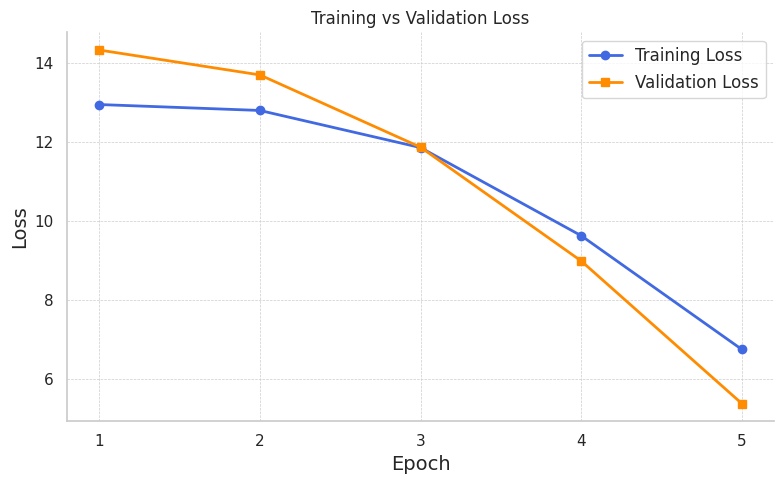

In [118]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

training_losses = [12.96, 12.81, 11.87, 9.64, 6.76]
validation_losses = [14.34, 13.71, 11.88, 9.00, 5.39]
epochs = range(1, 6)

plt.figure(figsize=(8, 5))
plt.plot(epochs, training_losses, marker='o', label='Training Loss', linewidth=2, color='royalblue')
plt.plot(epochs, validation_losses, marker='s', label='Validation Loss', linewidth=2, color='darkorange')

plt.title('Training vs Validation Loss')
plt.xlabel('Epoch', fontsize=14)
plt.ylabel('Loss', fontsize=14)
plt.xticks(epochs)
plt.legend(fontsize=12)
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
sns.despine()

plt.tight_layout()
plt.show()


In [33]:
!pip install rouge_score

## 5. Loading Saved Model and Getting Test Results

In [119]:
from transformers import T5ForConditionalGeneration, T5Tokenizer
from datasets import load_metric
import torch

model_path = "/content/t5_finetuned_final"
model = T5ForConditionalGeneration.from_pretrained(model_path)
tokenizer = T5Tokenizer.from_pretrained(model_path)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

rouge = load_metric("rouge")

In [132]:
predictions = []
references = []
for example in test_dataset.dataset:
    dialogue = example["dialogue"]
    inputs = tokenizer(dialogue, max_length=512, truncation=True, padding="max_length", return_tensors="pt").to(device)
    outputs = model.generate(inputs["input_ids"], max_length=512, num_beams=4, early_stopping=True)
    predicted_summary = tokenizer.decode(outputs[0], skip_special_tokens=True)
    predictions.append(predicted_summary)
    references.append(example["summary"])

results = rouge.compute(predictions=predictions, references=references)
print("ROUGE Scores:")
print(results)

print("\nSample Dialogue:")
print(test_dataset.dataset[0]["dialogue"])
print("\nGround Truth Summary:")
print(test_dataset.dataset[0]["summary"])
print("\nGenerated Summary:")
print(predictions[0])

ROUGE Scores:
{'rouge1': AggregateScore(low=Score(precision=np.float64(0.25972222222222224), recall=np.float64(0.2932307692307693), fmeasure=np.float64(0.27928744939271255)), mid=Score(precision=np.float64(0.34832930756843805), recall=np.float64(0.37411965811965814), fmeasure=np.float64(0.3614564279551337)), high=Score(precision=np.float64(0.444524959742351), recall=np.float64(0.45500854700854704), fmeasure=np.float64(0.4344918032786885))), 'rouge2': AggregateScore(low=Score(precision=np.float64(0.04092609003899329), recall=np.float64(0.05), fmeasure=np.float64(0.04481386748844378)), mid=Score(precision=np.float64(0.11155954844594396), recall=np.float64(0.10384615384615385), fmeasure=np.float64(0.10660606060606062)), high=Score(precision=np.float64(0.21012337662337652), recall=np.float64(0.18672179487179472), fmeasure=np.float64(0.19669830508474564))), 'rougeL': AggregateScore(low=Score(precision=np.float64(0.1550925925925926), recall=np.float64(0.16553846153846155), fmeasure=np.float6

In [137]:
original_length = len(test_dataset.dataset[0]["dialogue"])
summarized_length = len(predictions[0])

print(f"Original Length: {original_length}")
print(f"Summarized Length: {summarized_length}")

Original Length: 498
Summarized Length: 163


In [140]:
summarization_percentage = ((original_length - summarized_length) / original_length) * 100
print(f"Summarization Percentage: {summarization_percentage}")

Summarization Percentage: 67.26907630522089
